In [ ]:
import tensorflow as tf
#Encoder
def encoder_block(inputs,num_filters):
  x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(inputs)
  x=tf.keras.layers.Activation('relu')(x)
  x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(x)
  x=tf.keras.layers.Activation('relu')(x)
  x=tf.keras.layers.MaxPool2D(pool_size=(2,2),strides=2)(x)
  return x

#Decoder
def decoder_block(inputs,skip_features,num_filters):
  x=tf.keras.layers.Conv2DTranspose(num_filters,(2,2),strides=2,padding='same')(inputs)
  skip_features=tf.keras.layers.Resizing(x.shape[1],x.shape[2])(skip_features)

  x=tf.keras.layers.Concatenate()([x,skip_features])

  x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(x)
  x=tf.keras.layers.Activation('relu')(x)
  x=tf.keras.layers.Conv2D(num_filters,3,padding='same')(x)
  x=tf.keras.layers.Activation('relu')(x)
  return x

In [ ]:
import tensorflow as tf

def encoder_block(inputs, num_filters):

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(inputs)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.MaxPool2D(pool_size=(2, 2), strides=2)(x)

    return x

def decoder_block(inputs, skip_features, num_filters):

    x = tf.keras.layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='valid')(inputs)

    skip_features = tf.keras.layers.Resizing(x.shape[1], x.shape[2])(skip_features)

    x = tf.keras.layers.Concatenate()([x, skip_features])

    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Conv2D(num_filters, 3, padding='valid')(x)
    x = tf.keras.layers.Activation('relu')(x)

    return x

In [ ]:
def unet_model(input_shape=(256, 256, 3), num_classes=1):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Contracting Path (Encoder)
    s1 = encoder_block(inputs, 64)
    s2 = encoder_block(s1, 128)
    s3 = encoder_block(s2, 256)
    s4 = encoder_block(s3, 512)

    # Bottleneck
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(s4)
    b1 = tf.keras.layers.Activation('relu')(b1)
    b1 = tf.keras.layers.Conv2D(1024, 3, padding='same')(b1)
    b1 = tf.keras.layers.Activation('relu')(b1)

    # Expansive Path (Decoder)
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = tf.keras.layers.Conv2D(num_classes, 1, padding='same', activation='sigmoid')(d4)
    #outputs=
    model = tf.keras.models.Model(inputs=inputs, outputs=outputs, name='U-Net')
    return model

if __name__ == '__main__':
    model = unet_model(input_shape=(128, 128, 3), num_classes=5)
    model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[

 Total params: 31,032,005 (118.38 MB)

 Trainable params: 31,032,005 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 76.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 117.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="V4aqdc38b9ipUGYf1LyN")
project = rf.workspace("stagevisionparordinateur").project("real_hypodensity")
version = project.version(5)
dataset = version.download("png-mask-semantic")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Real_hypodensity-5 in png-mask-semantic:: 100%|██████████| 852/852 [00:00<00:00, 2484.20it/s]


In [ ]:
import tensorflow as tf
import os
#In my code image are already resized otherwise you must add it in process step
def load_image_and_mask(image_path,mask_path):
  image=tf.io.read_file(image_path)
  image=tf.cast(tf.image.decode_jpeg(image,channels=3),tf.float32)
  image=tf.image.resize(image,[128,128],method="nearest")/255.0
  #eVENTUAL RESIZE STEP

  mask=tf.io.read_file(mask_path)
  mask=tf.image.decode_png(mask,channels=1)
  #eVENTUAL RESIZE STEP
  mask=tf.image.resize(mask,[128,128],method="nearest")
  mask=tf.cast(mask,tf.uint8)

  return image,mask

def get_dataset(dir):
  image_files=sorted([f for f in os.listdir(dir) if f.endswith('.jpg')])
  images_paths=[os.path.join(dir,fname) for fname in image_files]
  mask_files=sorted([f for f in os.listdir(dir) if f.endswith('_mask.png')])
  mask_paths=[os.path.join(dir,fname) for fname in mask_files]

  ds=tf.data.Dataset.from_tensor_slices((images_paths,mask_paths))
  ds=ds.map(load_image_and_mask,num_parallel_calls=tf.data.AUTOTUNE)
  ds=ds.batch(16).prefetch(tf.data.AUTOTUNE)
  return ds
train_ds=get_dataset('/content/Real_hypodensity-5/train')
valid_ds=get_dataset('/content/Real_hypodensity-5/valid')
test_ds=get_dataset('/content/Real_hypodensity-5/test')


In [ ]:
class MeanIouCustom(tf.keras.metrics.MeanIoU):
  def __init__(self,num_classes,**kwargs):
    super().__init__(num_classes=num_classes,**kwargs)
  def update_state(self,y_true,y_pred,sample_weight=None):
    y_pred=tf.argmax(y_pred,axis=-1)
    return super().update_state(y_true,y_pred,sample_weight)

In [ ]:
model.compile(optimizer="Adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=[MeanIouCustom(num_classes=5),tf.keras.metrics.SparseCategoricalAccuracy()])

In [ ]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
history=model.fit(train_ds,validation_data=valid_ds,epochs=60,callbacks=early_stopping)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - loss: 4.2231 - mean_iou_custom: 0.1501 - sparse_categorical_accuracy: 0.6910 - val_loss: 1.3619 - val_mean_iou_custom: 0.1565 - val_sparse_categorical_accuracy: 0.7825
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 65s 233ms/step - loss: 1.1095 - mean_iou_custom: 0.1546 - sparse_categorical_accuracy: 0.7731 - val_loss: 0.6425 - val_mean_iou_custom: 0.1565 - val_sparse_categorical_accuracy: 0.7825
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - loss: 0.5875 - mean_iou_custom: 0.1546 - sparse_categorical_accuracy: 0.7731 - val_loss: 0.4970 - val_mean_iou_custom: 0.1565 - val_sparse_categorical_accuracy: 0.7825
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - loss: 0.4981 - mean_iou_custom: 0.1730 - sparse_categorical_accuracy: 0.7754 - val_loss: 0.4892 - val_mean_iou_custom: 0.1565 - val_sparse_categorical_accuracy: 0.7825
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 236ms/step - loss: 0.5045 - mean_iou_custom: 0.1561 - sparse_categori

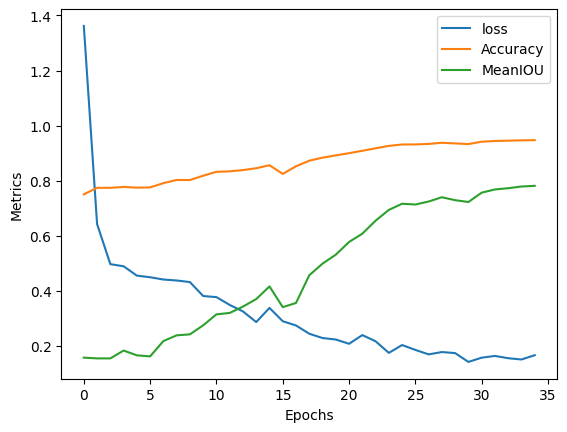

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_loss'])
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['mean_iou_custom'])
plt.legend(['loss','Accuracy','MeanIOU'])
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.show()

## PRETRAINED MODEL

In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Conv2D ,MaxPooling2D ,UpSampling2D,concatenate,Conv2DTranspose,BatchNormalization,Dropout ,Activation
def create_unet_model():
  base_model=tf.keras.applications.MobileNetV2(input_shape=[128,128,3],include_top=False)

  layer_names=[
      'block_1_expand_relu', # 4096
      'block_3_expand_relu', #1024
      'block_6_expand_relu', #256
      'block_13_expand_relu', #64
      'block_16_project',  #16
  ]

  base_model_outputs=[base_model.get_layer(name).output for name in layer_names]

  down_stack=tf.keras.Model(inputs=base_model.input,outputs=base_model_outputs)

  down_stack.trainable=False

  def conv_block(x,n_filters):
    x=Conv2D(n_filters,(3,3),padding='same',activation='relu')(x)
    x=Conv2D(n_filters,(3,3),padding='same',activation='relu')(x)
    print("X ...",x)
    return x

  def decoder_block(x,p,n_filters):
    x=Conv2DTranspose(n_filters,(2,2),strides=(2,2),padding='same')(x)
    print(f"X :{x} and P :{p}")
    x=concatenate([x,p])
    x=conv_block(x,n_filters)
    return x

  #up_stack
  class UP_STACK():
    def __init__(self,bridge,p1,p2,p3,p4):
      #bridge=conv_block(p4,n_filters=1024)
      self.u4=decoder_block(bridge,p4,n_filters=512)
      self.u3=decoder_block(self.u4,p3,n_filters=256)
      self. u2=decoder_block(self.u3,p2,n_filters=128)
      self.u1=decoder_block(self.u2,p1,n_filters=64)


  inputs=tf.keras.layers.Input(shape=[128,128,3])

  skips=down_stack(inputs)
  p1=skips[0]
  p2=skips[1]
  p3=skips[-3]
  p4=skips[-2]
  bridge=skips[-1]
  print(f"P1 :{p1} P2 :{p2} P3 :{p3} P4 :{p4}")
  up_stack=UP_STACK(bridge,p1,p2,p3,p4)
  #p4=skips[-1]
  print("U1 ",up_stack.u1)
  #outputs=Conv2DTranspose(filters=5,kernel_size=(1,1),strides=(2,2),activation='softmax')(up_stack.u1)
  outputs=Conv2D(filters=6,kernel_size=(1,1),activation='softmax')(up_stack.u1)
  #outputs=tf.keras.layers.Resizing(128,128,interpolation='nearest')(outputs)
  outputs=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(outputs)
  return Model(inputs=[inputs],outputs=[outputs])
model=create_unet_model()

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Conv2D ,MaxPooling2D ,UpSampling2D,concatenate,Conv2DTranspose,BatchNormalization,Dropout ,Activation
def create_unet_model():
  base_model=tf.keras.applications.MobileNetV2(input_shape=[128,128,3],include_top=False)

  layer_names=[
      'block_1_expand_relu', # 4096
      'block_3_expand_relu', #1024
      'block_6_expand_relu', #256
      'block_13_expand_relu', #64
      'block_16_project',  #16
  ]

  base_model_outputs=[base_model.get_layer(name).output for name in layer_names]

  down_stack=tf.keras.Model(inputs=base_model.input,outputs=base_model_outputs)

  down_stack.trainable=False



  #up_stack
  class UP_STACK():
    def __init__(self,bridge,p1,p2,p3,p4):
      #bridge=conv_block(p4,n_filters=1024)
      self.u4=decoder_block(bridge,p4,512)
      self.u3=decoder_block(self.u4,p3,256)
      self. u2=decoder_block(self.u3,p2,128)
      self.u1=decoder_block(self.u2,p1,64)


  inputs=tf.keras.layers.Input(shape=[128,128,3])

  skips=down_stack(inputs)
  p1=skips[0]
  p2=skips[1]
  p3=skips[-3]
  p4=skips[-2]
  bridge=skips[-1]
  print(f"P1 :{p1} P2 :{p2} P3 :{p3} P4 :{p4}")
  up_stack=UP_STACK(bridge,p1,p2,p3,p4)
  #p4=skips[-1]
  print("U1 ",up_stack.u1)
  #outputs=Conv2DTranspose(filters=5,kernel_size=(1,1),strides=(2,2),activation='softmax')(up_stack.u1)
  outputs=Conv2D(filters=6,kernel_size=(1,1),activation='softmax')(up_stack.u1)
  #outputs=tf.keras.layers.Resizing(128,128,interpolation='nearest')(outputs)
  outputs=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(outputs)
  return Model(inputs=[inputs],outputs=[outputs])
pre_model=create_unet_model()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
P1 :<KerasTensor shape=(None, 64, 64, 96), dtype=float32, sparse=False, ragged=False, name=keras_tensor_209> P2 :<KerasTensor shape=(None, 32, 32, 144), dtype=float32, sparse=False, ragged=False, name=keras_tensor_210> P3 :<KerasTensor shape=(None, 16, 16, 192), dtype=float32, sparse=False, ragged=False, name=keras_tensor_211> P4 :<KerasTensor shape=(None, 8, 8, 576), dtype=float32, sparse=False, ragged=False, name=keras_tensor_212>
U1  <KerasTensor shape=(None, 64, 64, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_241>


In [ ]:
pre_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ input_layer_2[0]… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 8, 8, 512) │    655,872 │ functional[0][4]  │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_4          │ (None, 8, 8, 576) │          0 │ functional[0][3]  │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 8, 8,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1088)             │            │ resizing_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 8, 8, 512) │  5,014,016 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_18       │ (None, 8, 8, 512) │          0 │ conv2d_19[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 8, 8, 512) │  2,359,808 │ activation_18[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_19       │ (None, 8, 8, 512) │          0 │ conv2d_20[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 16, 16,    │    524,544 │ activation_19[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_5          │ (None, 16, 16,    │          0 │ functional[0][2]  │
│ (Resizing)          │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_5       │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 448)              │            │ resizing_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │  1,032,448 │ concatenate_5[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_20       │ (None, 16, 16,    │          0 │ conv2d_21[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 16, 16,    │    590,080 │ activation_20[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_21       │ (None, 16, 16,    │          0 │ conv2d_22[0][0] 

 Total params: 12,773,382 (48.73 MB)

 Trainable params: 10,931,398 (41.70 MB)

 Non-trainable params: 1,841,984 (7.03 MB)

In [ ]:
pre_model.compile(optimizer="Adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=[MeanIouCustom(num_classes=5),tf.keras.metrics.SparseCategoricalAccuracy()])
early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
history=pre_model.fit(train_ds,validation_data=valid_ds,epochs=60,callbacks=early_stopping)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - loss: 1.1558 - mean_iou_custom_1: 0.1460 - sparse_categorical_accuracy: 0.6508 - val_loss: 0.4724 - val_mean_iou_custom_1: 0.2808 - val_sparse_categorical_accuracy: 0.7849
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.5120 - mean_iou_custom_1: 0.2794 - sparse_categorical_accuracy: 0.7873 - val_loss: 0.4129 - val_mean_iou_custom_1: 0.3820 - val_sparse_categorical_accuracy: 0.8277
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0.4472 - mean_iou_custom_1: 0.3204 - sparse_categorical_accuracy: 0.8142 - val_loss: 0.3688 - val_mean_iou_custom_1: 0.4290 - val_sparse_categorical_accuracy: 0.8469
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.4152 - mean_iou_custom_1: 0.3590 - sparse_categorical_accuracy: 0.8316 - val_loss: 0.2890 - val_mean_iou_custom_1: 0.5993 - val_sparse_categorical_accuracy: 0.9045
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.3619 - mean_iou_custom_1: 0.4520 - spars

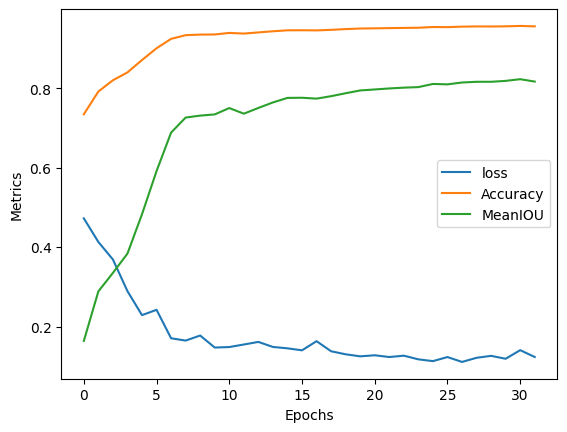

In [ ]:
plt.plot(history.history['val_loss'])
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['mean_iou_custom_1'])
plt.legend(['loss','Accuracy','MeanIOU'])
plt.xlabel('Epochs')
plt.ylabel('Metrics')
plt.show()

In [ ]:
def pre_unet_model():
  base_vgg_model=tf.keras.applications.VGG16(input_shape=[128,128,3],include_top=False)

  vgg_layer_names=[
      'block1_conv2', # 4096
      'block2_conv2', #1024
      'block3_conv3', #256
      'block4_conv3', #64
      'block5_conv3',  #16
  ]

  base_model_outputs=[base_vgg_model.get_layer(name).output for name in vgg_layer_names]

  down_stack=tf.keras.Model(inputs=base_vgg_model.input,outputs=base_model_outputs)

  down_stack.trainable=False



  #up_stack
  class UP_STACK():
    def __init__(self,bridge,p1,p2,p3,p4):
      #bridge=conv_block(p4,n_filters=1024)
      self.u4=decoder_block(bridge,p4,512)
      self.u3=decoder_block(self.u4,p3,256)
      self. u2=decoder_block(self.u3,p2,128)
      self.u1=decoder_block(self.u2,p1,64)


  inputs=tf.keras.layers.Input(shape=[128,128,3])

  skips=down_stack(inputs)
  p1=skips[0]
  p2=skips[1]
  p3=skips[-3]
  p4=skips[-2]
  bridge=skips[-1]
  print(f"P1 :{p1} P2 :{p2} P3 :{p3} P4 :{p4}")
  up_stack=UP_STACK(bridge,p1,p2,p3,p4)
  #p4=skips[-1]
  print("U1 ",up_stack.u1)
  #outputs=Conv2DTranspose(filters=5,kernel_size=(1,1),strides=(2,2),activation='softmax')(up_stack.u1)
  outputs=Conv2D(filters=6,kernel_size=(1,1),activation='softmax')(up_stack.u1)
  #outputs=tf.keras.layers.Resizing(128,128,interpolation='nearest')(outputs)
  #outputs=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(outputs)
  return Model(inputs=[inputs],outputs=[outputs])
vgg_model=pre_unet_model()

P1 :<KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_373> P2 :<KerasTensor shape=(None, 64, 64, 128), dtype=float32, sparse=False, ragged=False, name=keras_tensor_374> P3 :<KerasTensor shape=(None, 32, 32, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_375> P4 :<KerasTensor shape=(None, 16, 16, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_376>
U1  <KerasTensor shape=(None, 128, 128, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_405>


In [ ]:
vgg_model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_6        │ [(None, 128, 128, │ 14,714,688 │ input_layer_8[0]… │
│ (Functional)        │ 64), (None, 64,   │            │                   │
│                     │ 64, 128), (None,  │            │                   │
│                     │ 32, 32, 256),     │            │                   │
│                     │ (None, 16, 16,    │            │                   │
│                     │ 512), (None, 8,   │            │                   │
│                     │ 8, 512)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_16 │ (None, 16, 16,    │  1,049,088 │ functional_6[0][… │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_16         │ (None, 16, 16,    │          0 │ functional_6[0][… │
│ (Resizing)          │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1024)             │            │ resizing_16[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 16, 16,    │  4,719,104 │ concatenate_16[0… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_42       │ (None, 16, 16,    │          0 │ conv2d_46[0][0]   │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ activation_42[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_43       │ (None, 16, 16,    │          0 │ conv2d_47[0][0]   │
│ (Activation)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_17 │ (None, 32, 32,    │    524,544 │ activation_43[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_17         │ (None, 32, 32,    │          0 │ functional_6[0][… │
│ (Resizing)          │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 32, 32,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 512)              │            │ resizing_17[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 32, 32,    │  1,179,904 │ concatenate_17[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_44       │ (None, 32, 32,    │          0 │ conv2d_48[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 32, 32,    │    590,080 │ activation_44[0]… │
│                     │ 256)              │            │                 

 Total params: 25,854,982 (98.63 MB)

 Trainable params: 11,140,294 (42.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
vgg_model.compile(optimizer="Adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=[MeanIouCustom(num_classes=5),tf.keras.metrics.SparseCategoricalAccuracy()])

early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
#history=simple_unet.fit(trent_train,validation_data=valid_ds,epochs=60,callbacks=early_stopping)
vgg_history=vgg_model.fit(train_ds,validation_data=valid_ds,epochs=60,callbacks=early_stopping)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 24s 728ms/step - loss: 1.0756 - mean_iou_custom_3: 0.1695 - sparse_categorical_accuracy: 0.7498 - val_loss: 0.4384 - val_mean_iou_custom_3: 0.3071 - val_sparse_categorical_accuracy: 0.8147
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - loss: 0.4475 - mean_iou_custom_3: 0.3064 - sparse_categorical_accuracy: 0.8160 - val_loss: 0.3405 - val_mean_iou_custom_3: 0.4862 - val_sparse_categorical_accuracy: 0.8829
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 172ms/step - loss: 0.3779 - mean_iou_custom_3: 0.3831 - sparse_categorical_accuracy: 0.8536 - val_loss: 0.2472 - val_mean_iou_custom_3: 0.6130 - val_sparse_categorical_accuracy: 0.9138
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - loss: 0.2952 - mean_iou_custom_3: 0.5111 - sparse_categorical_accuracy: 0.8886 - val_loss: 0.2123 - val_mean_iou_custom_3: 0.7025 - val_sparse_categorical_accuracy: 0.9303
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 174ms/step - loss: 0.2403 - mean_iou_custom_3: 0.6320 

In [ ]:
def pre_unet_model():
  base_resnet_model=tf.keras.applications.ResNet50(input_shape=[128,128,3],include_top=False)

  resnet_layer_names = [
    'conv1_relu',
    'conv2_block3_out',
    'conv3_block4_out',
    'conv4_block6_out',
    'conv5_block3_out',
   ]

  base_model_outputs=[base_resnet_model.get_layer(name).output for name in resnet_layer_names]

  down_stack=tf.keras.Model(inputs=base_resnet_model.input,outputs=base_model_outputs)

  down_stack.trainable=False



  #up_stack
  class UP_STACK():
    def __init__(self,bridge,p1,p2,p3,p4):
      #bridge=conv_block(p4,n_filters=1024)
      self.u4=decoder_block(bridge,p4,512)
      self.u3=decoder_block(self.u4,p3,256)
      self. u2=decoder_block(self.u3,p2,128)
      self.u1=decoder_block(self.u2,p1,64)


  inputs=tf.keras.layers.Input(shape=[128,128,3])

  skips=down_stack(inputs)
  p1=skips[0]
  p2=skips[1]
  p3=skips[-3]
  p4=skips[-2]
  bridge=skips[-1]
  print(f"P1 :{p1} P2 :{p2} P3 :{p3} P4 :{p4}")
  up_stack=UP_STACK(bridge,p1,p2,p3,p4)
  #p4=skips[-1]
  print("U1 ",up_stack.u1)
  #outputs=Conv2DTranspose(filters=5,kernel_size=(1,1),strides=(2,2),activation='softmax')(up_stack.u1)
  outputs=Conv2D(filters=6,kernel_size=(1,1),activation='softmax')(up_stack.u1)
  #outputs=tf.keras.layers.Resizing(128,128,interpolation='nearest')(outputs)
  outputs=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(outputs)
  return Model(inputs=[inputs],outputs=[outputs])
resnet_model=pre_unet_model()

P1 :<KerasTensor shape=(None, 64, 64, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1178> P2 :<KerasTensor shape=(None, 32, 32, 256), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1179> P3 :<KerasTensor shape=(None, 16, 16, 512), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1180> P4 :<KerasTensor shape=(None, 8, 8, 1024), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1181>
U1  <KerasTensor shape=(None, 64, 64, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1210>


In [ ]:
resnet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_12       │ [(None, 64, 64,   │ 23,587,712 │ input_layer_15[0… │
│ (Functional)        │ 64), (None, 32,   │            │                   │
│                     │ 32, 256), (None,  │            │                   │
│                     │ 16, 16, 512),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 1024), (None, 4,  │            │                   │
│                     │ 4, 2048)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_28 │ (None, 8, 8, 512) │  4,194,816 │ functional_12[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_28         │ (None, 8, 8,      │          0 │ functional_12[0]… │
│ (Resizing)          │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_28      │ (None, 8, 8,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1536)             │            │ resizing_28[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_73 (Conv2D)  │ (None, 8, 8, 512) │  7,078,400 │ concatenate_28[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_66       │ (None, 8, 8, 512) │          0 │ conv2d_73[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_74 (Conv2D)  │ (None, 8, 8, 512) │  2,359,808 │ activation_66[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_67       │ (None, 8, 8, 512) │          0 │ conv2d_74[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_29 │ (None, 16, 16,    │    524,544 │ activation_67[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_29         │ (None, 16, 16,    │          0 │ functional_12[0]… │
│ (Resizing)          │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_29      │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 768)              │            │ resizing_29[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_75 (Conv2D)  │ (None, 16, 16,    │  1,769,728 │ concatenate_29[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_68       │ (None, 16, 16,    │          0 │ conv2d_75[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_76 (Conv2D)  │ (None, 16, 16,    │    590,080 │ activation_68[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_69       │ (None, 16, 16,    │          0 │ conv2d_76[0][0] 

 Total params: 40,970,310 (156.29 MB)

 Trainable params: 17,382,598 (66.31 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
resnet_model.compile(optimizer="Adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=[MeanIouCustom(num_classes=5),tf.keras.metrics.SparseCategoricalAccuracy()])

early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
#history=simple_unet.fit(trent_train,validation_data=valid_ds,epochs=60,callbacks=early_stopping)
resnet_history=resnet_model.fit(train_ds,validation_data=valid_ds,epochs=60,callbacks=early_stopping)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - loss: 0.9885 - mean_iou_custom_4: 0.1440 - sparse_categorical_accuracy: 0.6542 - val_loss: 0.6249 - val_mean_iou_custom_4: 0.2443 - val_sparse_categorical_accuracy: 0.7667
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.5890 - mean_iou_custom_4: 0.2300 - sparse_categorical_accuracy: 0.7755 - val_loss: 0.4792 - val_mean_iou_custom_4: 0.3587 - val_sparse_categorical_accuracy: 0.8344
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.4971 - mean_iou_custom_4: 0.3199 - sparse_categorical_accuracy: 0.8125 - val_loss: 0.3340 - val_mean_iou_custom_4: 0.5573 - val_sparse_categorical_accuracy: 0.8876
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.4101 - mean_iou_custom_4: 0.4009 - sparse_categorical_accuracy: 0.8368 - val_loss: 0.2522 - val_mean_iou_custom_4: 0.6464 - val_sparse_categorical_accuracy: 0.9125
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.3764 - mean_iou_custom_4: 0.4313 - spars

In [ ]:
efficient_layer_names = [
    'block2a_expand_activation',
    'block3a_expand_activation',
    'block4a_expand_activation',
    'block6a_expand_activation',
    'top_activation',
]

def pre_unet_model():
  base_efficient_model=tf.keras.applications.EfficientNetB0(input_shape=[128,128,3],include_top=False)

  efficient_layer_names = [
    'block2a_expand_activation',
    'block3a_expand_activation',
    'block4a_expand_activation',
    'block6a_expand_activation',
    'top_activation',
  ]

  base_model_outputs=[base_efficient_model.get_layer(name).output for name in efficient_layer_names]

  down_stack=tf.keras.Model(inputs=base_efficient_model.input,outputs=base_model_outputs)

  down_stack.trainable=False



  #up_stack
  class UP_STACK():
    def __init__(self,bridge,p1,p2,p3,p4):
      #bridge=conv_block(p4,n_filters=1024)
      self.u4=decoder_block(bridge,p4,512)
      self.u3=decoder_block(self.u4,p3,256)
      self. u2=decoder_block(self.u3,p2,128)
      self.u1=decoder_block(self.u2,p1,64)


  inputs=tf.keras.layers.Input(shape=[128,128,3])

  skips=down_stack(inputs)
  p1=skips[0]
  p2=skips[1]
  p3=skips[-3]
  p4=skips[-2]
  bridge=skips[-1]
  print(f"P1 :{p1} P2 :{p2} P3 :{p3} P4 :{p4}")
  up_stack=UP_STACK(bridge,p1,p2,p3,p4)
  #p4=skips[-1]
  print("U1 ",up_stack.u1)
  #outputs=Conv2DTranspose(filters=5,kernel_size=(1,1),strides=(2,2),activation='softmax')(up_stack.u1)
  outputs=Conv2D(filters=6,kernel_size=(1,1),activation='softmax')(up_stack.u1)
  #outputs=tf.keras.layers.Resizing(128,128,interpolation='nearest')(outputs)
  outputs=tf.keras.layers.UpSampling2D(size=(2,2),interpolation='nearest')(outputs)
  return Model(inputs=[inputs],outputs=[outputs])
efficient_model=pre_unet_model()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
P1 :<KerasTensor shape=(None, 64, 64, 96), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1452> P2 :<KerasTensor shape=(None, 32, 32, 144), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1453> P3 :<KerasTensor shape=(None, 16, 16, 240), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1454> P4 :<KerasTensor shape=(None, 8, 8, 672), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1455>
U1  <KerasTensor shape=(None, 64, 64, 64), dtype=float32, sparse=False, ragged=False, name=keras_tensor_1484>


In [ ]:
efficient_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional_14       │ [(None, 64, 64,   │  4,049,571 │ input_layer_17[0… │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 240),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 672), (None, 4,   │            │                   │
│                     │ 4, 1280)]         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_32 │ (None, 8, 8, 512) │  2,621,952 │ functional_14[0]… │
│ (Conv2DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_32         │ (None, 8, 8, 672) │          0 │ functional_14[0]… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_32      │ (None, 8, 8,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 1184)             │            │ resizing_32[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 8, 8, 512) │  5,456,384 │ concatenate_32[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_74       │ (None, 8, 8, 512) │          0 │ conv2d_82[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 8, 8, 512) │  2,359,808 │ activation_74[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_75       │ (None, 8, 8, 512) │          0 │ conv2d_83[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_33 │ (None, 16, 16,    │    524,544 │ activation_75[0]… │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_33         │ (None, 16, 16,    │          0 │ functional_14[0]… │
│ (Resizing)          │ 240)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_33      │ (None, 16, 16,    │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 496)              │            │ resizing_33[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 16, 16,    │  1,143,040 │ concatenate_33[0… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_76       │ (None, 16, 16,    │          0 │ conv2d_84[0][0]   │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 16, 16,    │    590,080 │ activation_76[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_77       │ (None, 16, 16,    │          0 │ conv2d_85[0][0] 

 Total params: 17,500,009 (66.76 MB)

 Trainable params: 13,450,438 (51.31 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
efficient_model.compile(optimizer="Adam",loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),metrics=[MeanIouCustom(num_classes=5),tf.keras.metrics.SparseCategoricalAccuracy()])

early_stopping=tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)
#history=simple_unet.fit(trent_train,validation_data=valid_ds,epochs=60,callbacks=early_stopping)
efficient_history=efficient_model.fit(train_ds,validation_data=valid_ds,epochs=60,callbacks=early_stopping)

Epoch 1/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - loss: 1.0902 - mean_iou_custom_5: 0.1404 - sparse_categorical_accuracy: 0.6547 - val_loss: 0.8166 - val_mean_iou_custom_5: 0.1596 - val_sparse_categorical_accuracy: 0.7830
Epoch 2/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - loss: 0.7181 - mean_iou_custom_5: 0.1758 - sparse_categorical_accuracy: 0.7724 - val_loss: 0.5571 - val_mean_iou_custom_5: 0.2584 - val_sparse_categorical_accuracy: 0.7968
Epoch 3/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 0.5723 - mean_iou_custom_5: 0.2703 - sparse_categorical_accuracy: 0.7920 - val_loss: 0.4896 - val_mean_iou_custom_5: 0.3392 - val_sparse_categorical_accuracy: 0.8098
Epoch 4/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 0.5402 - mean_iou_custom_5: 0.3233 - sparse_categorical_accuracy: 0.8018 - val_loss: 0.5090 - val_mean_iou_custom_5: 0.3366 - val_sparse_categorical_accuracy: 0.8060
Epoch 5/60
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - loss: 0.5380 - mean_iou_custom_5: 0.3167 - spar

# Comparatif

In [ ]:
first=model.evaluate(test_ds)
#sec=vgg_model.evaluate(test_ds)
th=resnet_model.evaluate(test_ds)
four=efficient_model.evaluate(test_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.1454 - mean_iou_custom: 0.7914 - sparse_categorical_accuracy: 0.9482 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.1679 - mean_iou_custom_4: 0.7507 - sparse_categorical_accuracy: 0.9367
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.1987 - mean_iou_custom_5: 0.7189 - sparse_categorical_accuracy: 0.9288


(array([1., 0., 0., 0., 0., 1., 0., 0., 0., 1.]),
 array([0.71675575, 0.72348529, 0.73021482, 0.73694436, 0.7436739 ,
        0.75040343, 0.75713297, 0.76386251, 0.77059205, 0.77732158,
        0.78405112]),
 <BarContainer object of 10 artists>)

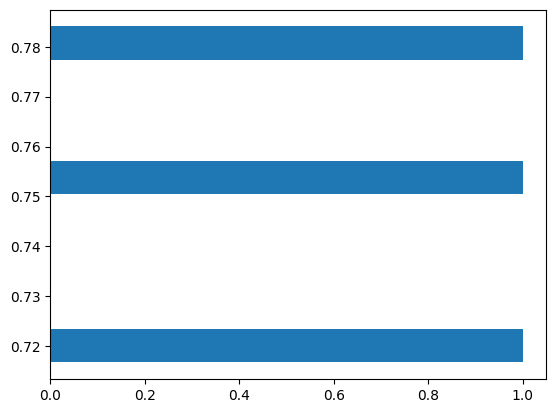

In [ ]:
import seaborn as sns
plt.hist([first[1],th[1],four[1]],orientation='horizontal')